<table style="width:100%; font-size:11pt; border-collapse:collapse">
    <tr>
        <td colspan="2"
            style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   text-align:center;
                   font-weight:bold;
                   padding:8px;">
            Universidad de Oriente
        </td>
    </tr>
    <tr>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
                            Machine Learning
        </td>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
            Clase 08 - Ejemplo 1 - Regresión lineal
        </td>
    </tr>
    <tr>
 

</table>

## Ejemplo 1

Se va a realizar un modelo de regresión lineal sobre el conjunto de datos que se
encuentra en rls_ex1.csv. rls_ex1 contiene la productividad de distintos procesos industriales
de diferentes empresas, donde la variable $X$ contiene las horas de trabajo
realizadas y la variable $Y$ contiene las ganancias de dicho proceso.

In [2]:
import pandas as pd
import numpy as np
from pandas.core.common import flatten
from plotnine import *
from array import *
import scipy.stats as stats
import math
import matplotlib as mpl
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms

Una vez cargadas las librerías necesarias, el primer paso consiste en cargar el archivo
en un data.frame mediante la función pd.read_csv(). Cuando se explora un conjunto
de datos por primera vez es conveniente realizar el método .describe() sobre el mismo.

In [3]:
datos_reg = pd.read_csv("rls_ex1.csv")
datos_reg

,x,y
0,62.675661,517.097007
1,166.254106,1071.822371
2,122.397254,501.610387
3,38.997767,159.227305
4,48.466506,159.289701
5,75.726504,167.745255
6,115.779915,603.760399
7,48.359412,151.642354
8,220.862737,727.021883
9,27.618049,89.704189


Cuando se explora un conjunto de datos por primera vez es conveniente realizar el método .describe() sobre el mismo.

In [4]:
datos_reg.describe()

,x,y
count,34.000000,34.000000
mean,86.478831,523.345975
std,60.683849,443.033484
min,11.761794,89.704189
25%,48.386186,177.947704
50%,73.586046,367.889547
75%,114.434185,793.047566
max,243.544835,1833.782283


Se observa que se tienen 34 observaciones y que no existen datos faltantes. Se procede a elaborar un histograma y un gráfico de caja y bigotes

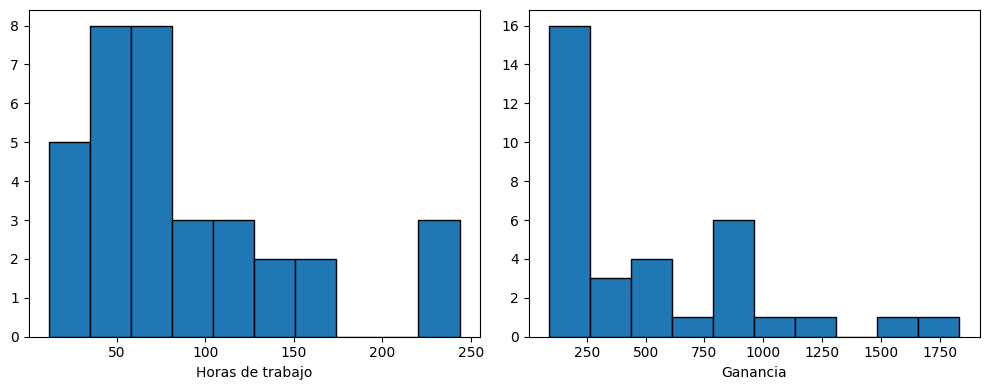

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))


axes[0].hist(datos_reg.x, bins=10, edgecolor='black')
axes[0].set_xlabel('Horas de trabajo')

axes[1].hist(datos_reg.y, bins=10, edgecolor='black')
axes[1].set_xlabel('Ganancia')

plt.tight_layout()
plt.show()

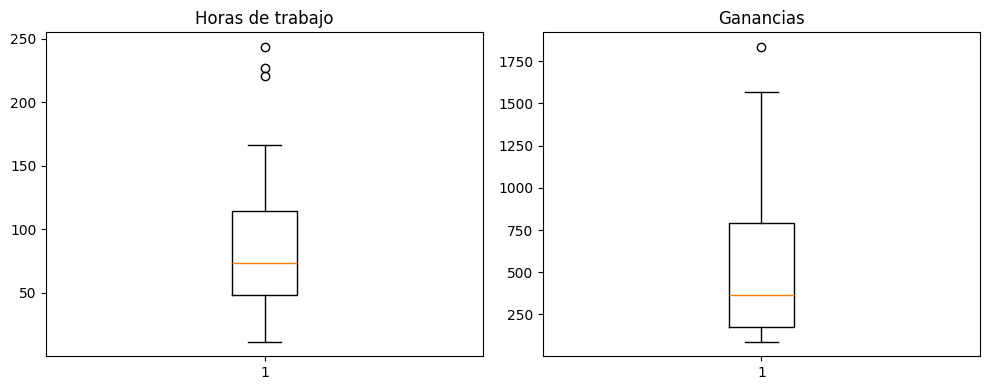

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))


axes[0].boxplot(datos_reg.x)
axes[0].set_title("Horas de trabajo")
axes[1].boxplot(datos_reg.y)
axes[1].set_title("Ganancias")

plt.tight_layout()
plt.show()

De los gráficos se puede observar que ambas variables poseen datos atípicos, lo que puede influir en los resultados del modelo de regresión. Ahora, se 
comprueba visualmente en un gráfico de dispersió3, si existe algun 
relación entr$e$ X $e$ Y .

<function matplotlib.pyplot.show(close=None, block=None)>

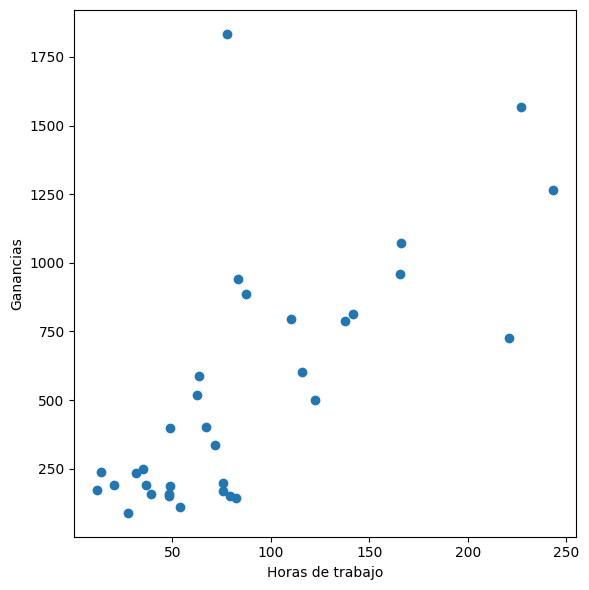

In [7]:
#Representar x e y
fig = plt.figure(figsize=(6,6))
plt.scatter(datos_reg.x, datos_reg.y)
#Colocar etiquetas a los ejes
plt.xlabel("Horas de trabajo")
plt.ylabel("Ganancias")

plt.tight_layout()
plt.show

Se aprecia que podría existir una correlación lineal entre ambas variables, a pesar de
que hay un dato que podría ser un outlier. Se procede a ajustar un modelo de regresión
lineal con el paquete Scikit-Learn. Para poder introducir las variables en el modelo de
regresión es necesario definirlas como un array de 2 dimensiones

In [9]:
#Extraer variables y convertir en np.array
x = datos_reg["x"].values.reshape(-1, 1)
y = datos_reg["y"].values.reshape(-1, 1)
# Crear el modelo de regresión
from sklearn.linear_model import LinearRegression
lm = LinearRegression()

#Ajustar el modelo con los datos x,y
lm.fit(x,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [10]:
#Se muestran los parámetros del modelo creado
intercepto = lm.intercept_
coeficiente = lm.coef_

print("El intercepto del modelo es %s" %intercepto)
print("El coeficiente del modelo es %s" %coeficiente)

El intercepto del modelo es [77.19092689]
El coeficiente del modelo es [[5.1591244]]


La recta de regresión obtenida se puede introducir en la gráfica anterior. Hay que tener en cuenta que para poder dibujar la recta de regresión es necesario antes definir una variable que contenga los valores ajustados de $y$, es decir, los $\hat{y}$ del modelo

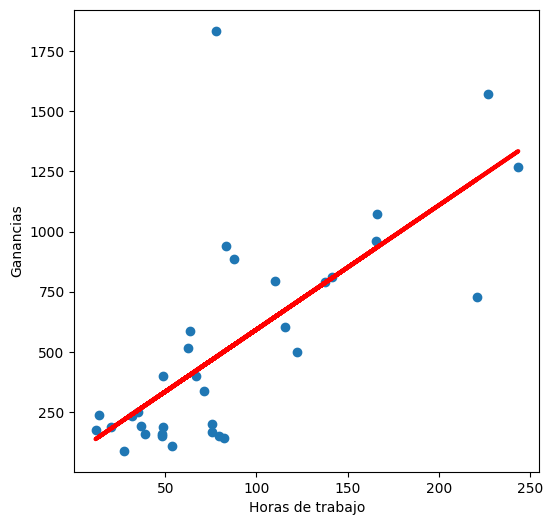

In [11]:
#Representar x e y
fig = plt.figure(figsize=(6,6))
plt.scatter(x, y)

#Representar recta de regresión
y_pred = lm.predict(x)
plt.plot(x, y_pred, color='red', linewidth=3)

plt.xlabel("Horas de trabajo")
plt.ylabel("Ganancias")
plt.show()

In [12]:
#Ecuacion de la recta
print("La ecuacion de la recta de regresion es y=%s+%s x" %(intercepto, coeficiente))

La ecuacion de la recta de regresion es y=[77.19092689]+[[5.1591244]] x


## Coeficiente de determinación

También se puede obtener el coeficiente de determinación, $R^2$, del modelo. El coeficiente
de determinación se puede calcular mediante la función de Scikit-Learn r2_score(),
en la cual debemos introducir como argumentos los valores reales de la muestra observada
de la variable $Y$ , es decir, la variable (el array) $y$ en Python, y la variable $y_{pred}$

In [13]:
#Cálculo de R^2
r2 = r2_score(y, y_pred)
print("EL coeficiente de determinacipon es %s" %r2)

EL coeficiente de determinacipon es 0.49937309079191006


Este resultado indica que existe asociación entre la variable predictora y la variable
respuesta, pero el modelo no consigue explicar, aproximadamente, la mitad de la
varianza total, en términos de suma de cuadrados de la respuesta.

## Varianza del modelo

Se puede obtener una estimación de la varianza del modelo, aplicando la función
mean_squared_error(), en la cual debemos introducir como argumentos, de nuevo,
los valores de $y$ e $\tilde{y}$. Se puede comprobar que el estimador de la varianza del modelo
obtenido es el correspondiente al método de máxima verosimilitud

In [14]:
#Cálculo de la varianza
varianza = mean_squared_error(y, y_pred)
print("La varianza del modelo es %s" %varianza)
#Varianza por máxima verosimilitud (MLE)
y_resta = (y-y_pred)**2
varianza_MLE = np.sum(y_resta)/34
print("La varianza del modelo por MLE es %s" %varianza_MLE)

#Varianza por mínimos cuadrados ordinarios (OLS)
varianza_OLS = np.sum(y_resta)/34 #n-2
print("La varianza del modelo por OLS es %s" %varianza_OLS)

La varianza del modelo es 95372.31261031816
La varianza del modelo por MLE es 95372.31261031816
La varianza del modelo por OLS es 95372.31261031816


Para comprobar la bondad del ajuste del modelo, aparte del coeficiente de determinación
y de la varianza, se puede realizar un gráfico donde se comparan los
valores reales de la muestra frente a los valores del ajuste. Cuanto más se aproximen
los puntos del gráfico de dispersión a la bisectriz del primer cuadrante, mejor será el
ajuste del modelo.

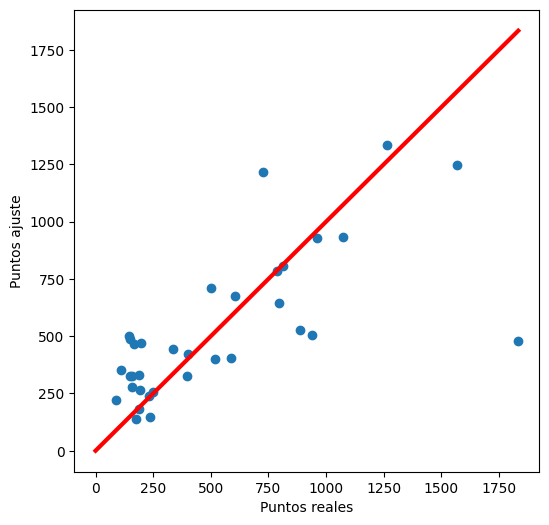

In [15]:
#Representar reales vs predichos

fig = plt.figure(figsize=(6,6))
plt.scatter(y, y_pred)
plt.xlabel("Puntos reales")
plt.ylabel("Puntos ajuste")
plt.plot([0, np.max(y)], [0, np.max(y)], color = 'red', linewidth = 3)
plt.show()

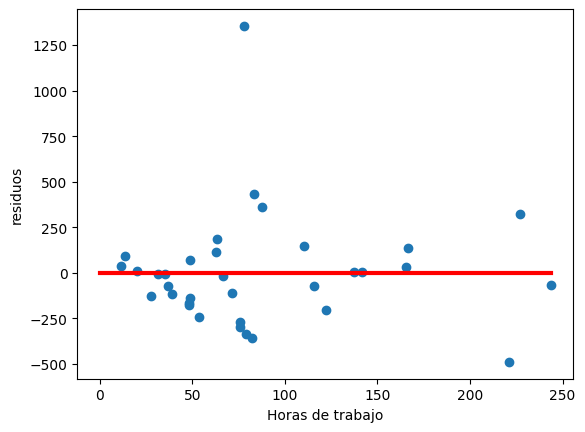

In [16]:
#Obtener residuos

residuos1 = y - y_pred
plt.figure()
plt.scatter(x, residuos1)
plt.xlabel("Horas de trabajo")
plt.ylabel("residuos")
plt.plot([0, np.max(x)], [0, 0], color = 'red', linewidth = 3)
plt.show()

Gráficamente, los residuos se distribuyen sin tendencia apreciable, pero con un outlier
entre las 50 y las 100 horas, por lo que podemos sospechar de que se cumpla la
normalidad

In [17]:
#Se realiza la prueba de Saphiro
sh_result = stats.shapiro(residuos1)

#Mostrar los resultadod de la prueba
print("Test Shapiro-Wilk, p.valor: %5.5f" %(sh_result.pvalue))

Test Shapiro-Wilk, p.valor: 0.00002


In [18]:
m1 = sm.OLS(y, sm.add_constant(x)).fit()
bp1 = sms.het_breuschpagan(resid = m1.resid,
exog_het = m1.model.exog)[1]
print("El resultado del test Breusch-Pagan es: p.valor = %5.3f" %(bp1))

El resultado del test Breusch-Pagan es: p.valor = 0.834


Con los resultados de los test, se comprueba la homegeneidad de la varianza de los
residuos, pero no su normalidad. Por lo tanto, sería necesario estudiar la procedencia
del outlier para ver si se trata de un dato bien tomado. Solo en
este segundo caso debería eliminarse. Si no es posible eliminar el punto anómalo, cabría
plantearse cambiar de modelo de regresión, realizar alguna transformación sobre la
variable $Y$.

Fin